In [53]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/amazon-fine-food-reviews/hashes.txt
/kaggle/input/amazon-fine-food-reviews/Reviews.csv
/kaggle/input/amazon-fine-food-reviews/database.sqlite
/kaggle/input/amazon-product-reviews/ratings_Electronics (1).csv


In [54]:
!pip install nltk spacy
!python -m spacy download en_core_web_sm

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 69.0 MB/s eta 0:00:00:00:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [55]:
import re
import spacy
from nltk.corpus import stopwords

In [56]:
nlp = spacy.load("en_core_web_sm")

In [57]:
import pandas as pd
import numpy as np

df = pd.read_csv("/kaggle/input/amazon-fine-food-reviews/Reviews.csv")
# limit it to first 5000

df = df.head(5000)

In [58]:
df.shape

(5000, 10)

In [59]:
def preprocess(text):
    # removal of special chars and URL
    text = re.sub(r'http\S+', '',text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # lematization and stopword removal
    doc = nlp(text.lower())
    tokens = [token.lemma_ for token in doc if not token.is_stop and token.is_alpha]
    return ' '.join(tokens)

df['cleaned_feedback'] = df['Text'].apply(preprocess)

In [60]:
# Semantic analysis
!pip install vaderSentiment

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [61]:
# Rule Based
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = analyzer.polarity_scores(text)
    if score['compound'] > 0.05:
        return 'Positive'
    elif score['compound'] < - 0.05:
        return 'Negative'
    else: 
        return 'Neutral'

df['sentiment'] = df['cleaned_feedback'].apply(get_sentiment)

In [62]:
# ML 
!pip install transformers torch

from transformers import pipeline

classifier = pipeline('sentiment-analysis',
    model="distilbert-base-uncased-finetuned-sst-2-english",
    )
def bert_sentiments(text):
    result = classifier(text[:512]) #max length
    return result[0]['label']

df['sentiment'] = df['cleaned_feedback'].apply(bert_sentiments)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Device set to use cpu


In [63]:
# analysis and visualization
!pip install wordcloud



huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [64]:
print(df['sentiment'].unique())

['POSITIVE' 'NEGATIVE']


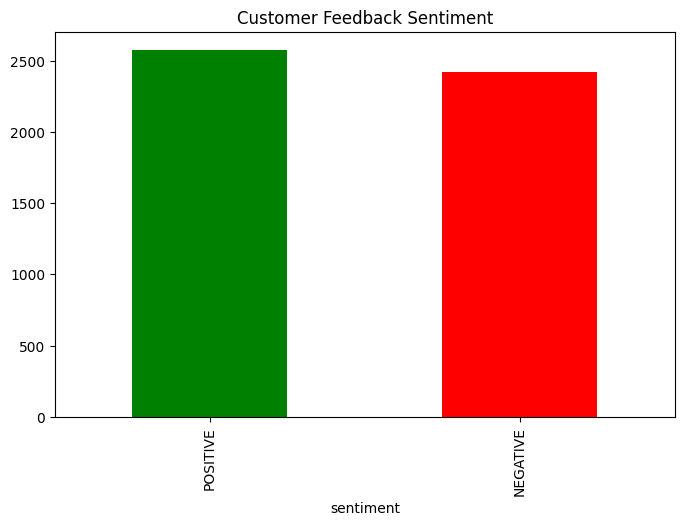

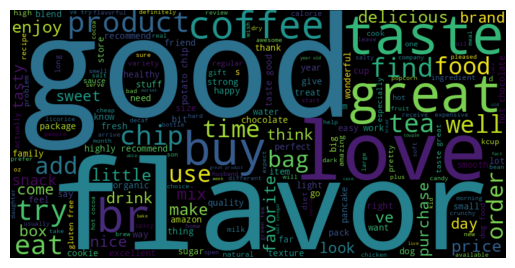

In [65]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Plot sentiment distribution
plt.figure(figsize=(8, 5))
df['sentiment'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Customer Feedback Sentiment')
plt.show()

# word cloud for positive reviews

positive_text = ' '.join(df[df['sentiment'] == 'POSITIVE']['cleaned_feedback'])
wordcloud = WordCloud(width = 800, height=400).generate(positive_text)
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis('off')
plt.show()